# Notebook 11 — Rhyme Density

We compute phonetic rhyme features for each song using the **CMU Pronouncing Dictionary** (via the `pronouncing` library). For each pair of nearby lines, we check whether they rhyme by comparing the trailing phonemes.

**Metrics computed per song:**
- **Rhyme density**: fraction of line pairs (within a sliding window) that rhyme
- **Rhyme stretch**: how far apart can rhyming lines be? Higher = more sophisticated structure
- **Multi-syllabic rhyme rate**: pairs that match 2+ syllables, not just the last vowel sound

**Caveats** (worth flagging in the writeup):
- CMU dictionary misses contemporary slang ("tryna", "ayy", "shawty", "ain't" spelled "aint")
- Doesn't detect slant rhymes that hip-hop relies on
- 2014 cutoff means new words missing
- For unknown words, we fall back to spelling-based suffix matching (last 3 letters)

Despite these limits, we expect **clear genre and era patterns** — hip-hop should have much higher rhyme density than other genres, and rhyme complexity should rise over time.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

tqdm.pandas()
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13, 5)

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
df = pd.read_parquet(PROCESSED_DIR / "songs_with_topics.parquet")
df_en = df[df["language"] == "en"].copy().reset_index(drop=True)
print(f"English songs: {len(df_en):,}")

English songs: 6,538


## Build a phoneme lookup function

`pronouncing.phones_for_word()` returns CMU phonemes. We extract the "rhyme tail" — the phonemes from the last stressed vowel onward (the standard definition of what rhymes).

For words not in the dictionary, we fall back to using the word's spelling suffix as a rough phonetic approximation.

In [3]:
import re
import pronouncing
from functools import lru_cache

# Strip everything but letters and apostrophes
WORD_RE = re.compile(r"[a-zA-Z]+(?:'[a-zA-Z]+)?")

@lru_cache
def rhyme_tail(word: str) -> str:
    """Get the rhyme tail (last stressed vowel onward) for a word.
    Returns a string of phonemes joined by spaces, or '' if no info."""
    word = word.lower().strip()
    if not word:
        return ""
    
    phones_list = pronouncing.phones_for_word(word)
    if phones_list:
        # rhyming_part returns the tail from last stressed vowel
        tail = pronouncing.rhyming_part(phones_list[0])
        return tail if tail else ""
    
    # Fallback: use last 3 letters of the word as a pseudo-phoneme
    return f"SPELL_{word[-3:]}" if len(word) >= 3 else f"SPELL_{word}"

# Quick test
for w in ["fire", "desire", "trying", "ayy", "shawty"]:
    print(f"  {w!r:12} → {rhyme_tail(w)!r}")

  'fire'       → 'AY1 ER0'
  'desire'     → 'AY1 ER0'
  'trying'     → 'AY1 IH0 NG'
  'ayy'        → 'SPELL_ayy'
  'shawty'     → 'SPELL_wty'


## Extract the last word of each line and compute its rhyme tail

For each song, we get the sequence of "rhyme tails" — one per line. Then we score rhymes between lines.

In [16]:
def line_rhyme_tails(lyrics: str) -> list[str]:
    """Return list of rhyme tails, one per non-empty line."""
    tails = []
    for line in lyrics.split("\n"):
        words = WORD_RE.findall(line)
        if not words:
            continue
        last_word = words[-1].lower()
        tails.append(rhyme_tail(last_word))
    return tails

def rhyme_features(lyrics: str, window: int = 4) -> dict:
    """
    Compute rhyme features for one song.
    For each line, check whether its rhyme tail matches any of the previous 
    `window` lines. Returns several aggregate stats.
    """
    tails = line_rhyme_tails(lyrics)
    if len(tails) < 2:
        return {"rhyme_density": 0.0, "mean_stretch": 0.0, 
                "max_stretch": 0, "n_lines_used": len(tails)}
    
    rhyme_count = 0
    total_pairs = 0
    stretches = []  # how many lines back was the rhyme partner?
    
    for i in range(1, len(tails)):
        if not tails[i]:
            continue
        # Look back up to `window` lines
        for back in range(1, min(window + 1, i + 1)):
            j = i - back
            if not tails[j]:
                continue
            total_pairs += 1
            if tails[i] == tails[j] and tails[i] != "":
                rhyme_count += 1
                stretches.append(back)
                break  # don't double-count — first match within window is enough
    
    return {
        "rhyme_density": rhyme_count / max(len(tails) - 1, 1),
        "mean_stretch": np.mean(stretches) if stretches else 0.0,
        "max_stretch": max(stretches) if stretches else 0,
        "n_lines_used": len(tails),
    }

# Compute for all English songs — this is the slow step (a few minutes)
features = df_en["lyrics_text"].progress_apply(rhyme_features)
features_df = pd.DataFrame(features.tolist())
for col in features_df.columns:
    df_en[col] = features_df[col].values

print("\nRhyme stats:")
print(df_en[["rhyme_density", "mean_stretch", "max_stretch"]].describe())

  0%|          | 0/6538 [00:00<?, ?it/s]


Rhyme stats:
       rhyme_density  mean_stretch  max_stretch
count    6538.000000   6538.000000  6538.000000
mean        0.388484      1.843880     3.441878
std         0.148711      0.512278     0.841629
min         0.000000      0.000000     0.000000
25%         0.285714      1.473684     3.000000
50%         0.380952      1.791667     4.000000
75%         0.483049      2.141626     4.000000
max         1.000000      4.000000     4.000000


In [17]:
def rhyme_tail_relaxed(word: str, level: int = 2) -> str:
    """Trailing phonemes for slant-rhyme detection.
    level=1: last vowel sound only (very permissive)
    level=2: last 2 phonemes (catches slant rhymes)
    level=3: last 3 phonemes (closer to perfect rhyme)
    """
    full_tail = rhyme_tail(word)
    if not full_tail or full_tail.startswith("SPELL_"):
        return full_tail
    phonemes = full_tail.split()
    if level == 1:
        # Just the last vowel sound (strip stress digits)
        vowels = [p for p in phonemes if any(c.isdigit() for c in p)]
        return vowels[-1].rstrip("012") if vowels else ""
    return " ".join(p.rstrip("012") for p in phonemes[-level:])


def rhyme_features_v2(lyrics: str, window: int = 4) -> dict:
    """Computes three rhyme densities: strict / slant / vowel-only."""
    lines_with_words = []
    for line in lyrics.split("\n"):
        words = WORD_RE.findall(line)
        if words:
            lines_with_words.append(words[-1].lower())
    
    if len(lines_with_words) < 2:
        return {"rhyme_density_strict": 0.0, "rhyme_density_slant": 0.0,
                "rhyme_density_vowel": 0.0, "n_lines_used_v2": len(lines_with_words)}
    
    strict_tails = [rhyme_tail(w) for w in lines_with_words]
    slant_tails = [rhyme_tail_relaxed(w, level=2) for w in lines_with_words]
    vowel_tails = [rhyme_tail_relaxed(w, level=1) for w in lines_with_words]
    
    def count_matches(tails):
        count = 0
        for i in range(1, len(tails)):
            if not tails[i]:
                continue
            for back in range(1, min(window + 1, i + 1)):
                if tails[i-back] and tails[i] == tails[i-back]:
                    count += 1
                    break
        return count / max(len(tails) - 1, 1)
    
    return {
        "rhyme_density_strict": count_matches(strict_tails),
        "rhyme_density_slant": count_matches(slant_tails),
        "rhyme_density_vowel": count_matches(vowel_tails),
        "n_lines_used_v2": len(lines_with_words),
    }


features = df_en["lyrics_text"].progress_apply(rhyme_features_v2)
features_df = pd.DataFrame(features.tolist())
for col in features_df.columns:
    df_en[col] = features_df[col].values

print(df_en[["rhyme_density_strict", "rhyme_density_slant", 
              "rhyme_density_vowel"]].describe())

  0%|          | 0/6538 [00:00<?, ?it/s]

       rhyme_density_strict  rhyme_density_slant  rhyme_density_vowel
count           6538.000000          6538.000000          6538.000000
mean               0.388484             0.406929             0.566126
std                0.148711             0.146240             0.115447
min                0.000000             0.000000             0.000000
25%                0.285714             0.305085             0.487805
50%                0.380952             0.400000             0.563733
75%                0.483049             0.500000             0.642857
max                1.000000             1.000000             1.000000


## Rhyme density over time

Has pop music gotten more rhyme-heavy over the decades?

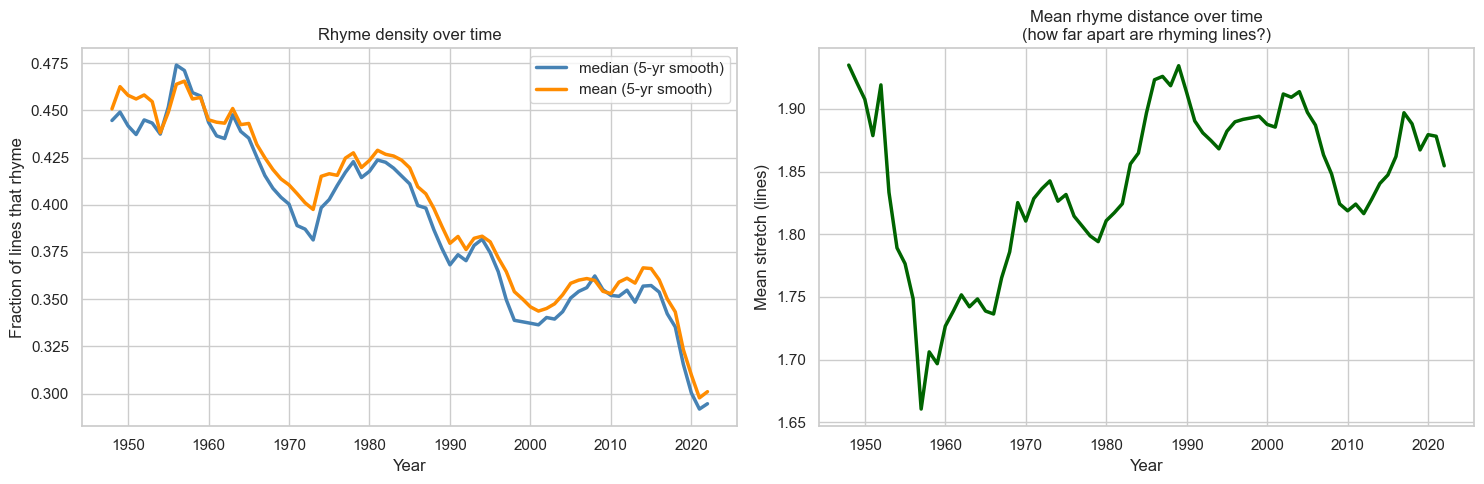

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Per-year rhyme density
yearly = df_en.groupby("year")["rhyme_density"].agg(["median", "mean"])
axes[0].plot(yearly.index, yearly["median"].rolling(5, center=True).mean(),
              color="steelblue", linewidth=2.5, label="median (5-yr smooth)")
axes[0].plot(yearly.index, yearly["mean"].rolling(5, center=True).mean(),
              color="darkorange", linewidth=2.5, label="mean (5-yr smooth)")
axes[0].set_title("Rhyme density over time")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Fraction of lines that rhyme")
axes[0].legend()

# Rhyme stretch over time  
yearly_stretch = df_en.groupby("year")["mean_stretch"].mean()
axes[1].plot(yearly_stretch.index, yearly_stretch.rolling(5, center=True).mean(),
              color="darkgreen", linewidth=2.5)
axes[1].set_title("Mean rhyme distance over time\n(how far apart are rhyming lines?)")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Mean stretch (lines)")

plt.tight_layout(); plt.show()

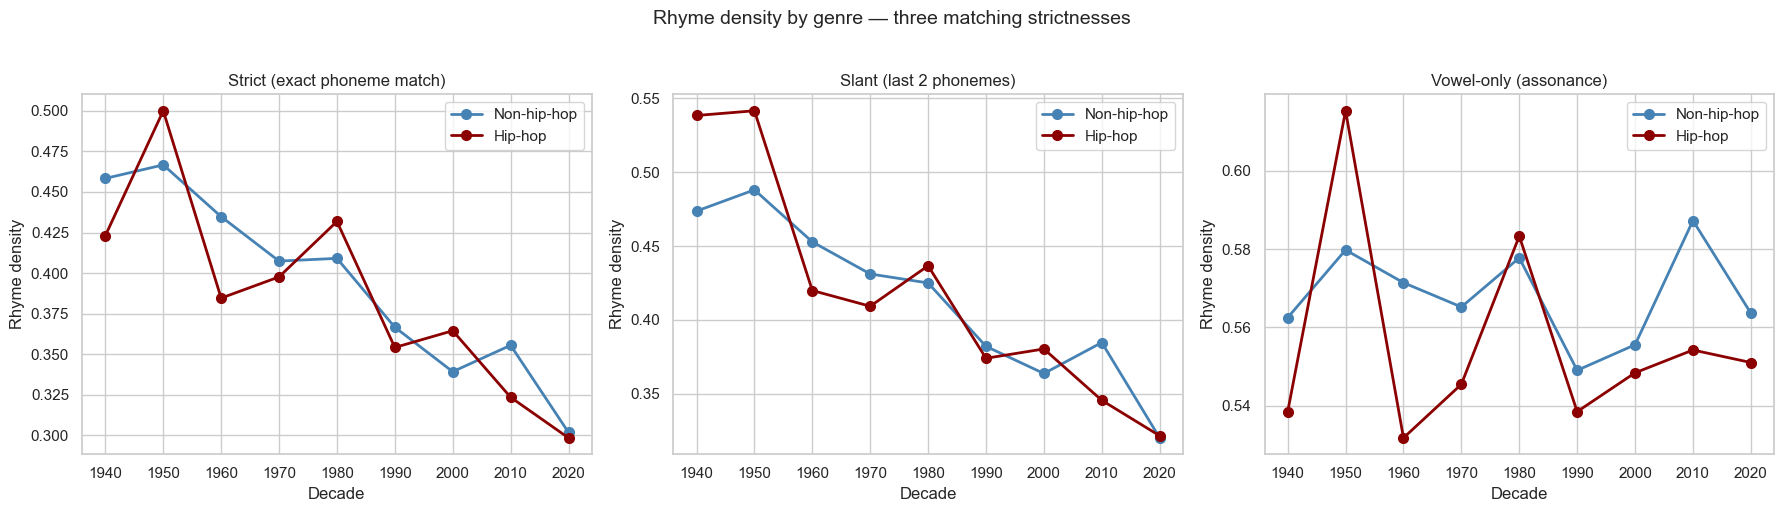


Median rhyme density (slant), by decade × genre:
is_hiphop  False  True 
decade                 
1940       0.474  0.538
1950       0.488  0.542
1960       0.453  0.420
1970       0.431  0.409
1980       0.425  0.437
1990       0.382  0.374
2000       0.364  0.380
2010       0.385  0.345
2020       0.320  0.321

Median rhyme density (vowel-only), by decade × genre:
is_hiphop  False  True 
decade                 
1940       0.562  0.538
1950       0.580  0.615
1960       0.571  0.532
1970       0.565  0.545
1980       0.578  0.583
1990       0.549  0.538
2000       0.556  0.548
2010       0.587  0.554
2020       0.564  0.551


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

metrics = [
    ("rhyme_density_strict", "Strict (exact phoneme match)", axes[0]),
    ("rhyme_density_slant",  "Slant (last 2 phonemes)",        axes[1]),
    ("rhyme_density_vowel",  "Vowel-only (assonance)",         axes[2]),
]

for col, title, ax in metrics:
    for is_hh, color, label in [(False, "steelblue", "Non-hip-hop"),
                                  (True, "darkred", "Hip-hop")]:
        sub = df_en[df_en["is_hiphop"] == is_hh]
        dec = sub.groupby("decade")[col].median()
        ax.plot(dec.index, dec.values, "o-", color=color, linewidth=2,
                markersize=7, label=label)
    ax.set_title(title)
    ax.set_xlabel("Decade")
    ax.set_ylabel("Rhyme density")
    ax.legend()

plt.suptitle("Rhyme density by genre — three matching strictnesses", 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nMedian rhyme density (slant), by decade × genre:")
print(df_en.groupby(["decade", "is_hiphop"])["rhyme_density_slant"]
            .median().unstack().round(3))

print("\nMedian rhyme density (vowel-only), by decade × genre:")
print(df_en.groupby(["decade", "is_hiphop"])["rhyme_density_vowel"]
            .median().unstack().round(3))

## By genre tag (hip-hop vs. non-hip-hop)

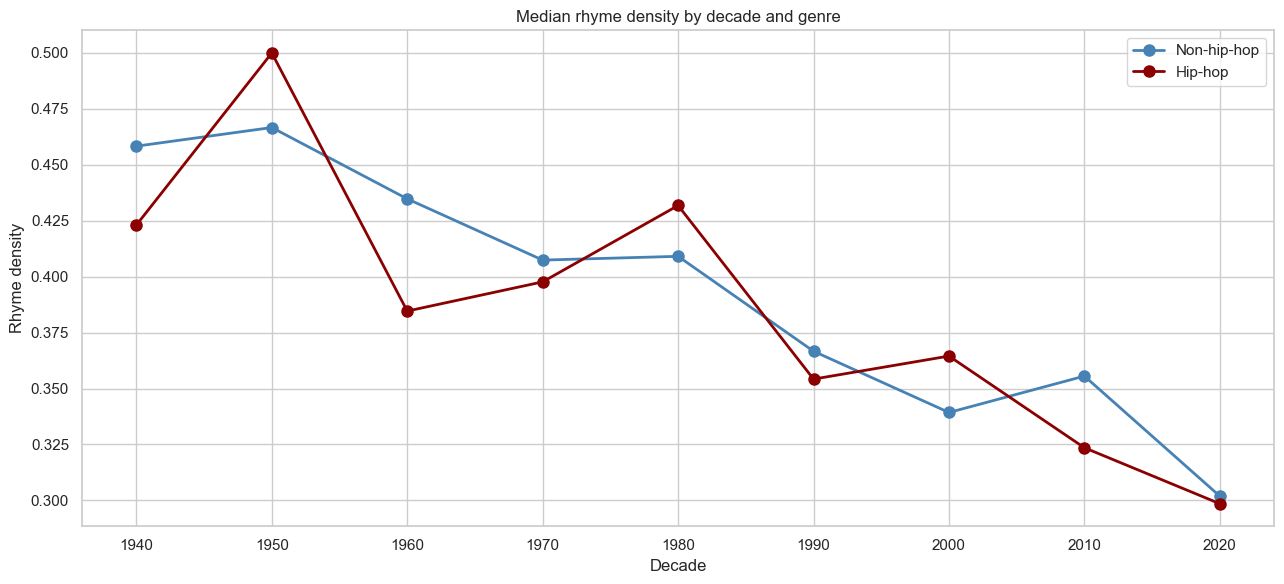


Median rhyme density:
is_hiphop  False  True 
decade                 
1940       0.458  0.423
1950       0.467  0.500
1960       0.435  0.385
1970       0.407  0.398
1980       0.409  0.432
1990       0.367  0.354
2000       0.339  0.365
2010       0.356  0.324
2020       0.302  0.299


In [20]:
HIPHOP_MARKERS = {
    "tryna", "gon", "i'ma", "imma", "ain't", "nah", "bout", "lemme", "finna",
    "lil", "ayy", "yuh", "huh", "nigga", "niggas", "homie", "shawty",
    "bitch", "bitches", "shit", "fuck", "fuckin", "fucking",
}
df_en["hh_count"] = df_en["tokens"].apply(
    lambda toks: sum(1 for t in toks if t in HIPHOP_MARKERS)
)
df_en["is_hiphop"] = df_en["hh_count"] / df_en["n_tokens"] >= 0.01

fig, ax = plt.subplots(figsize=(13, 6))
for is_hh, color, label in [(False, "steelblue", "Non-hip-hop"),
                              (True, "darkred", "Hip-hop")]:
    sub = df_en[df_en["is_hiphop"] == is_hh]
    dec = sub.groupby("decade")["rhyme_density"].median()
    ax.plot(dec.index, dec.values, "o-", color=color, linewidth=2,
            markersize=8, label=label)
ax.set_title("Median rhyme density by decade and genre")
ax.set_xlabel("Decade"); ax.set_ylabel("Rhyme density")
ax.legend()
plt.tight_layout(); plt.show()

print("\nMedian rhyme density:")
print(df_en.groupby(["decade", "is_hiphop"])["rhyme_density"]
            .median().unstack().round(3))

## Most rhyme-dense songs and artists

In [23]:
# Top 25 rhyme-densest songs
print("Most rhyme-dense songs (≥30 lines, to filter out short fragments):")
top_rhyme = df_en[df_en["n_lines_used"] >= 30].nlargest(25, "rhyme_density")[
    ["year", "title", "artist", "rhyme_density", "n_lines_used"]
]
print(top_rhyme.to_string(index=False))

# Artist averages (min 6 songs)
df_en["primary_artist"] = df_en["artist"].apply(
    lambda s: re.split(r"\s+(?:featuring|feat\.?|ft\.?|with|&|\+|and|x)\s+",
                       s, maxsplit=1, flags=re.IGNORECASE)[0].split(",")[0].strip()
)
artist_rhymes = (df_en.groupby("primary_artist")
                       .agg(mean_density=("rhyme_density", "mean"),
                            n_songs=("id", "count"))
                       .query("n_songs >= 6")
                       .sort_values("mean_density", ascending=False))

print("\n\nTop 20 most rhyme-dense artists (≥6 charting songs):")
print(artist_rhymes.head(20).round(3))

print("\nLeast rhyme-dense artists:")
print(artist_rhymes.tail(15).round(3)[::-1])

Most rhyme-dense songs (≥30 lines, to filter out short fragments):
 year                                           title                               artist  rhyme_density  n_lines_used
 1973                        Dancing in the Moonlight                         King Harvest       0.948718            40
 1964                                    Surfin' Bird                         The Trashmen       0.916667            73
 1968                             Time Has Come Today                The Chambers Brothers       0.890909            56
 1995                                  Cotton Eye Joe                               Rednex       0.884615            53
 1983                                          Mickey                           Toni Basil       0.857143            78
 1965                         All I Really Want to Do                                 Cher       0.852941            35
 1986                                  A Love Bizarre                            Sheila E.   

In [24]:
artist_rhymes_v2 = (df_en.groupby("primary_artist")
                          .agg(strict=("rhyme_density_strict", "mean"),
                               slant=("rhyme_density_slant", "mean"),
                               vowel=("rhyme_density_vowel", "mean"),
                               n_songs=("id", "count"))
                          .query("n_songs >= 6"))

print("Top 20 by SLANT rhyme density:")
print(artist_rhymes_v2.sort_values("slant", ascending=False).head(20).round(3))

print("\nTop 20 by VOWEL-ONLY rhyme density (most permissive):")
print(artist_rhymes_v2.sort_values("vowel", ascending=False).head(20).round(3))

# Where do the famous rappers actually rank?
spotlight_artists = ["Eminem", "Drake", "Jay-Z", "Kanye West", "Nicki Minaj",
                      "Kendrick Lamar", "Lil Wayne", "Ludacris", "50 Cent",
                      "Olivia Rodrigo", "Taylor Swift", "Ed Sheeran"]
print("\nWhere do specific artists rank?")
for a in spotlight_artists:
    if a in artist_rhymes_v2.index:
        row = artist_rhymes_v2.loc[a]
        rank_slant = (artist_rhymes_v2["slant"] > row["slant"]).sum() + 1
        rank_vowel = (artist_rhymes_v2["vowel"] > row["vowel"]).sum() + 1
        total = len(artist_rhymes_v2)
        print(f"  {a:<20}  slant={row['slant']:.3f} (rank {rank_slant}/{total})"
              f"  vowel={row['vowel']:.3f} (rank {rank_vowel}/{total})")

Top 20 by SLANT rhyme density:
                       strict  slant  vowel  n_songs
primary_artist                                      
Patti Page              0.543  0.601  0.695       11
Culture Club            0.567  0.594  0.671        6
KC                      0.591  0.591  0.657        6
War                     0.564  0.582  0.673        6
Steve Winwood           0.544  0.581  0.669        6
Tommy James             0.550  0.574  0.665        7
Roy Orbison             0.564  0.569  0.639        8
The Dave Clark Five     0.558  0.558  0.631        7
Cyndi Lauper            0.517  0.551  0.642        6
The Beach Boys          0.525  0.547  0.644       12
The Shirelles           0.525  0.534  0.616        6
Johnny Rivers           0.519  0.530  0.648        6
Jackie Wilson           0.512  0.526  0.612        6
Perry Como              0.498  0.526  0.613       20
Coldplay                0.488  0.525  0.658        8
David Guetta            0.505  0.523  0.652        7
Gary Lewis     

## Cross-validate: does rhyme density correlate with topic?

In [22]:
# Mean rhyme density per topic
if "topic_label" in df_en.columns:
    topic_rhyme = (df_en.groupby("topic_label")["rhyme_density"]
                         .agg(["mean", "count"])
                         .sort_values("mean", ascending=False))
    print("Mean rhyme density per discovered topic:")
    print(topic_rhyme.round(3))

Mean rhyme density per discovered topic:
                                 mean  count
topic_label                                 
Dance / party                   0.441    266
Devotional love (classic)       0.435    273
Pop love (generic)              0.409   2841
Christmas classics              0.393     10
R&B / rap-pop crossover         0.391    540
Heartbreak ballads              0.381    302
Third-person love               0.379    249
Existential / world-themed      0.364    231
Apology / regret / kiss-off     0.360    230
Dark / cinematic                0.358    100
Introspection / dark emotional  0.354    293
Mixed (low signal)              0.354    207
Country / Americana             0.352    240
Hip-hop / rap                   0.336    463
Storytelling / narrative        0.328    293


In [10]:
df_en.to_parquet(PROCESSED_DIR / "songs_with_rhyme.parquet")
print(f"Saved {len(df_en):,} songs with rhyme features")

Saved 6,538 songs with rhyme features
